<a href="https://colab.research.google.com/github/unVeroz007/2311532008_Muhammad-Galis-Avero_ImageProcessing/blob/main/Pertemuan12/2311532008_Muhammad_Galid_Avero_Tugas_Image_Processing_Pertemuan_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Install & Import Python

In [2]:
!pip install opencv-python-headless matplotlib numpy --quiet

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
print(" Setup selesai!")

 Setup selesai!


#Upload Gambar

Saving Daun.jpg to Daun (1).jpg
Gambar berhasil dimuat → Shape: (256, 256, 3)


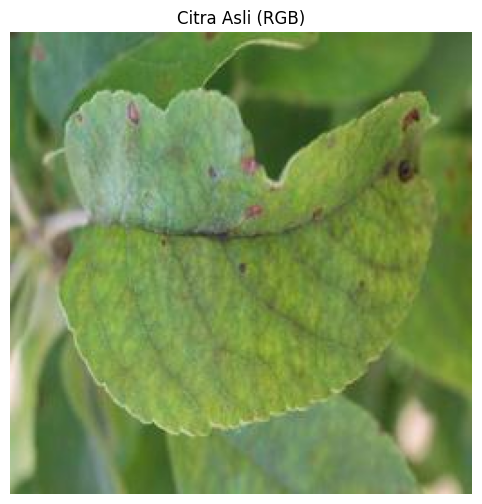

In [3]:
uploaded = files.upload()
img_path = 'Daun.jpg'
img = cv2.imread(img_path)

if img is None:
    print("Gambar tidak ditemukan! Upload ulang.")
else:
    print(f"Gambar berhasil dimuat → Shape: {img.shape}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,6))
    plt.imshow(img_rgb)
    plt.title('Citra Asli (RGB)')
    plt.axis('off')
    plt.show()

# 1 & 2. Citra Asli + Grayscale


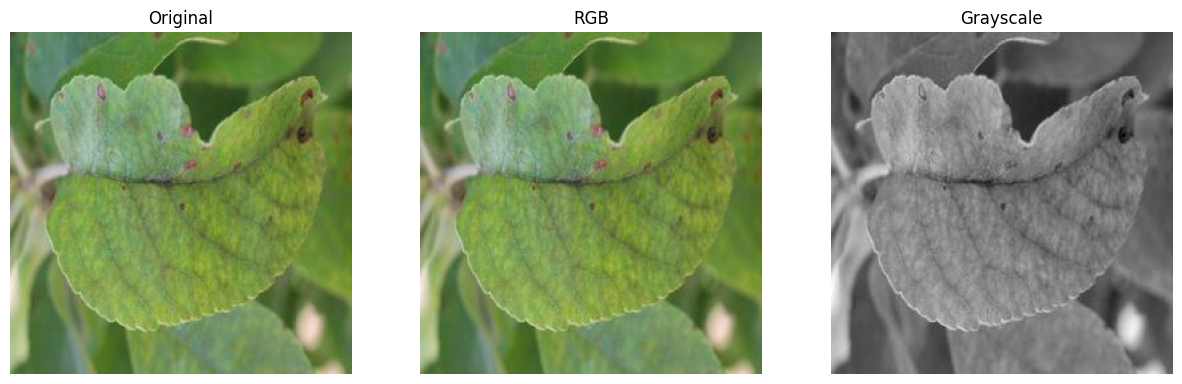

In [4]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(img_rgb); plt.title('RGB'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(gray, cmap='gray'); plt.title('Grayscale'); plt.axis('off')
plt.show()

#3. Masking Lingkaran Tengah


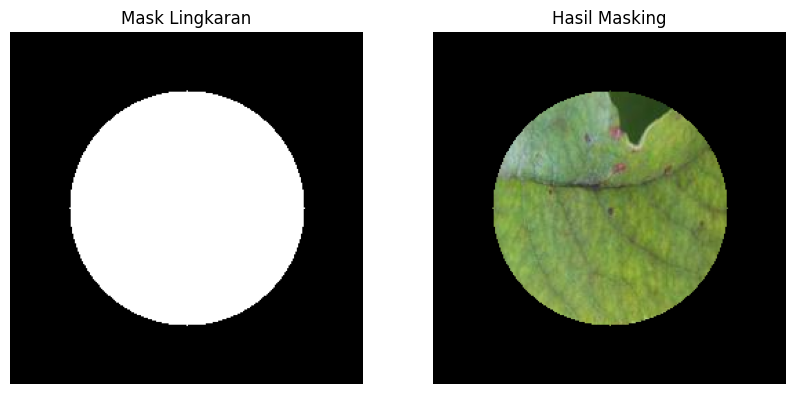

In [5]:
h, w = img.shape[:2]
mask = np.zeros((h, w), dtype=np.uint8)
center = (w//2, h//2)
radius = min(h, w)//3
cv2.circle(mask, center, radius, 255, -1)

masked_img = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(mask, cmap='gray'); plt.title('Mask Lingkaran'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(masked_img); plt.title('Hasil Masking'); plt.axis('off')
plt.show()

#4. Split & Merge Kanal RGB


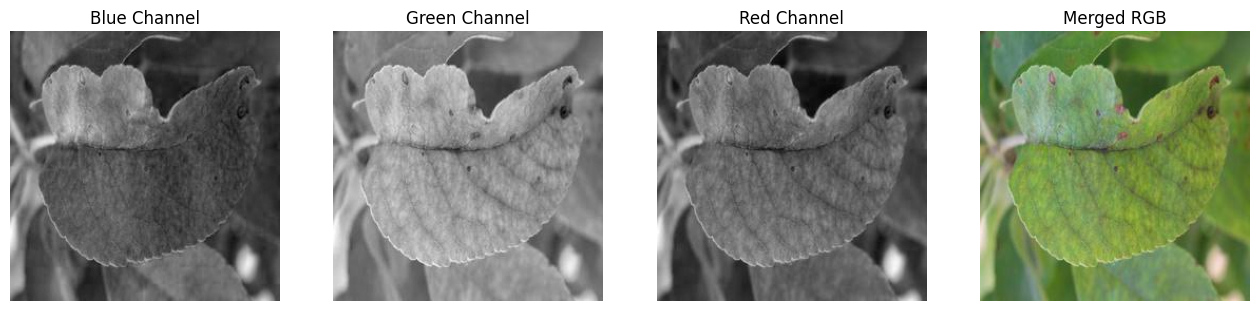

In [16]:
b, g, r = cv2.split(img)
merged = cv2.merge([b, g, r])

plt.figure(figsize=(16,5))
plt.subplot(1,4,1); plt.imshow(b, cmap='gray'); plt.title('Blue Channel'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(g, cmap='gray'); plt.title('Green Channel'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(r, cmap='gray'); plt.title('Red Channel'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(cv2.cvtColor(merged, cv2.COLOR_BGR2RGB)); plt.title('Merged RGB'); plt.axis('off')
plt.show()

#5. Histogram Grayscale & Warna


/tmp/ipykernel_15931/2883012081.py:3: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0,256])


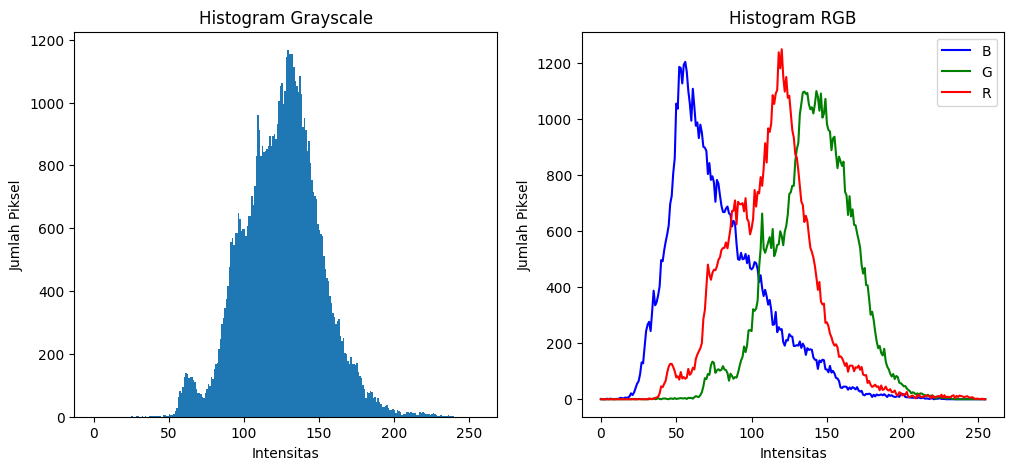

In [7]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(gray.ravel(), 256, [0,256])
plt.title('Histogram Grayscale')
plt.xlabel('Intensitas'); plt.ylabel('Jumlah Piksel')

plt.subplot(1,2,2)
color = ('b','g','r')
for i, col in enumerate(color):
    histr = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr, color=col, label=col.upper())
plt.title('Histogram RGB')
plt.xlabel('Intensitas'); plt.ylabel('Jumlah Piksel')
plt.legend()
plt.show()

#6. Histogram Equalization


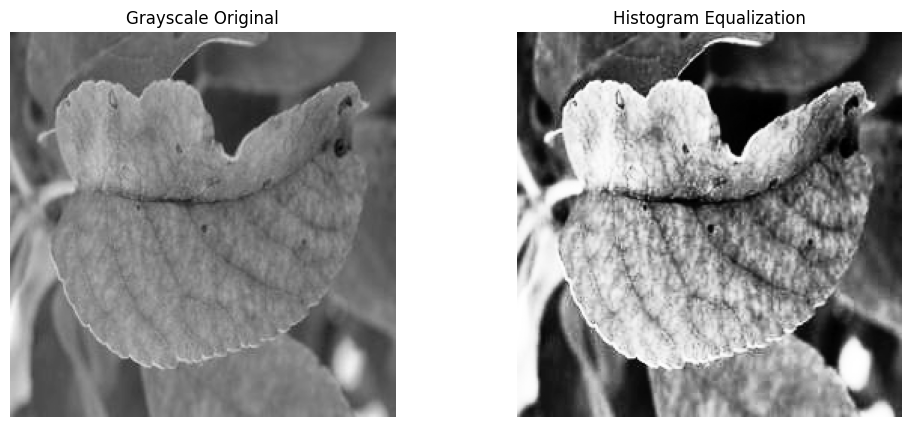

/tmp/ipykernel_15931/3711043159.py:9: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(), 256, [0,256], alpha=0.7, label='Original')
/tmp/ipykernel_15931/3711043159.py:10: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(equalized.ravel(), 256, [0,256], alpha=0.7, label='Equalized')


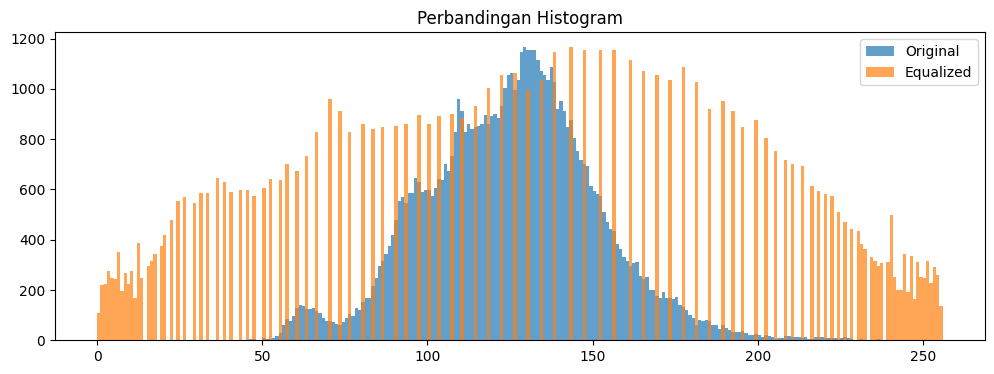

In [8]:
equalized = cv2.equalizeHist(gray)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title('Grayscale Original'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(equalized, cmap='gray'); plt.title('Histogram Equalization'); plt.axis('off')
plt.show()

# Perbandingan histogram
plt.figure(figsize=(12,4))
plt.hist(gray.ravel(), 256, [0,256], alpha=0.7, label='Original')
plt.hist(equalized.ravel(), 256, [0,256], alpha=0.7, label='Equalized')
plt.title('Perbandingan Histogram'); plt.legend(); plt.show()

#7. Berbagai Blur


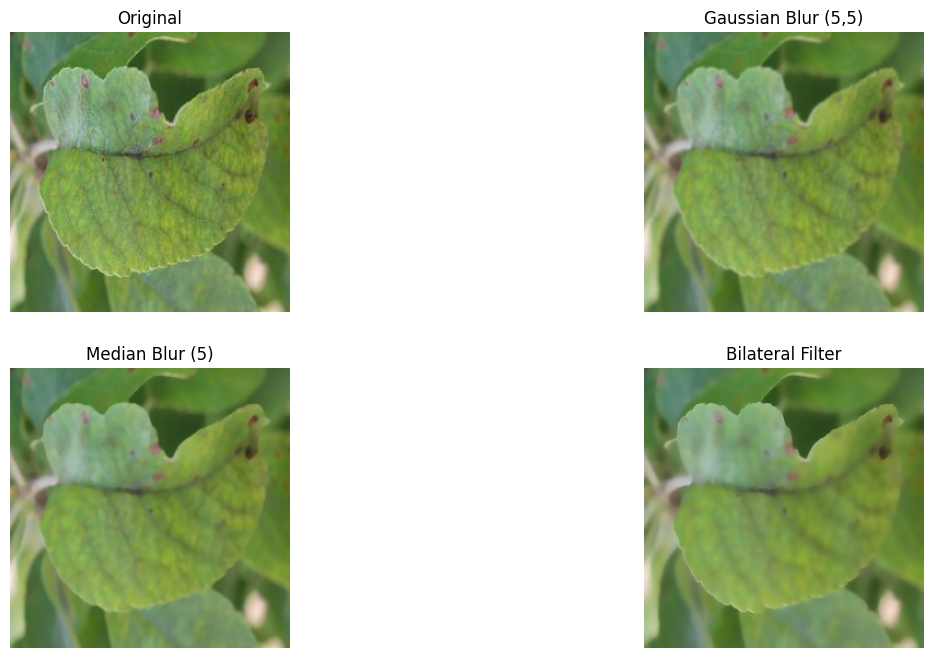

In [9]:
gaussian = cv2.GaussianBlur(img_rgb, (5,5), 0)
median = cv2.medianBlur(img_rgb, 5)
bilateral = cv2.bilateralFilter(img_rgb, 9, 75, 75)

plt.figure(figsize=(15,8))
plt.subplot(2,2,1); plt.imshow(img_rgb); plt.title('Original'); plt.axis('off')
plt.subplot(2,2,2); plt.imshow(gaussian); plt.title('Gaussian Blur (5,5)'); plt.axis('off')
plt.subplot(2,2,3); plt.imshow(median); plt.title('Median Blur (5)'); plt.axis('off')
plt.subplot(2,2,4); plt.imshow(bilateral); plt.title('Bilateral Filter'); plt.axis('off')
plt.show()

#8. Thresholding


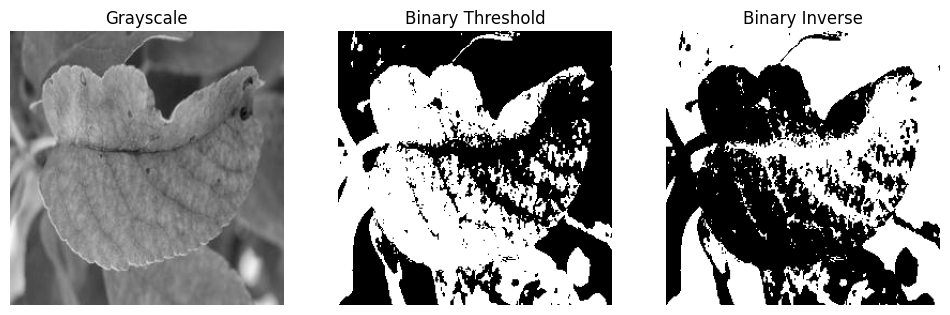

In [10]:
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
_, binary_inv = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(gray, cmap='gray'); plt.title('Grayscale'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(binary, cmap='gray'); plt.title('Binary Threshold'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(binary_inv, cmap='gray'); plt.title('Binary Inverse'); plt.axis('off')
plt.show()

#9. Deteksi Gradien Scharr


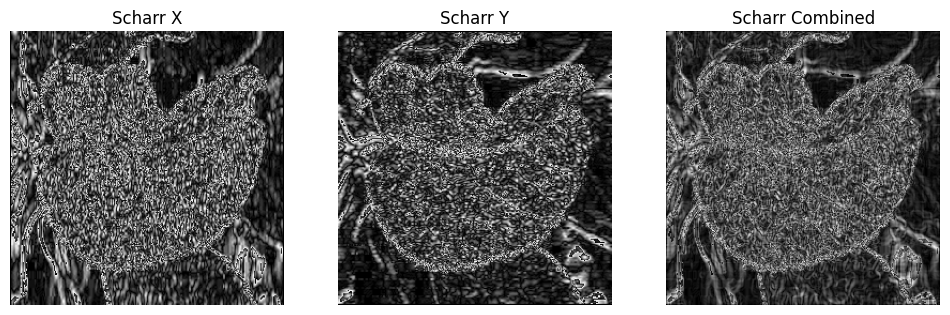

In [11]:
scharr_x = cv2.Scharr(gray, cv2.CV_64F, 1, 0)
scharr_y = cv2.Scharr(gray, cv2.CV_64F, 0, 1)
scharr_abs_x = np.uint8(np.absolute(scharr_x))
scharr_abs_y = np.uint8(np.absolute(scharr_y))
scharr_combined = cv2.addWeighted(scharr_abs_x, 0.5, scharr_abs_y, 0.5, 0)

plt.figure(figsize=(12,5))
plt.subplot(1,3,1); plt.imshow(scharr_abs_x, cmap='gray'); plt.title('Scharr X'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(scharr_abs_y, cmap='gray'); plt.title('Scharr Y'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(scharr_combined, cmap='gray'); plt.title('Scharr Combined'); plt.axis('off')
plt.show()

#10. Deteksi Tepi Canny

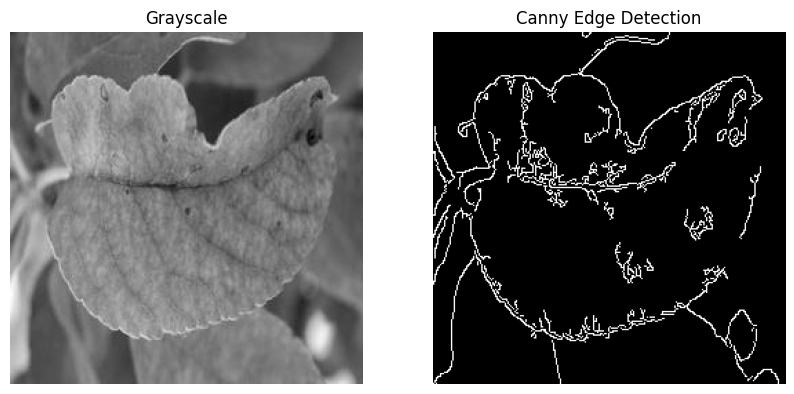

In [12]:
edges = cv2.Canny(gray, 50, 150)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(gray, cmap='gray'); plt.title('Grayscale'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(edges, cmap='gray'); plt.title('Canny Edge Detection'); plt.axis('off')
plt.show()

#EKSPERIMEN VARIASI PARAMETER


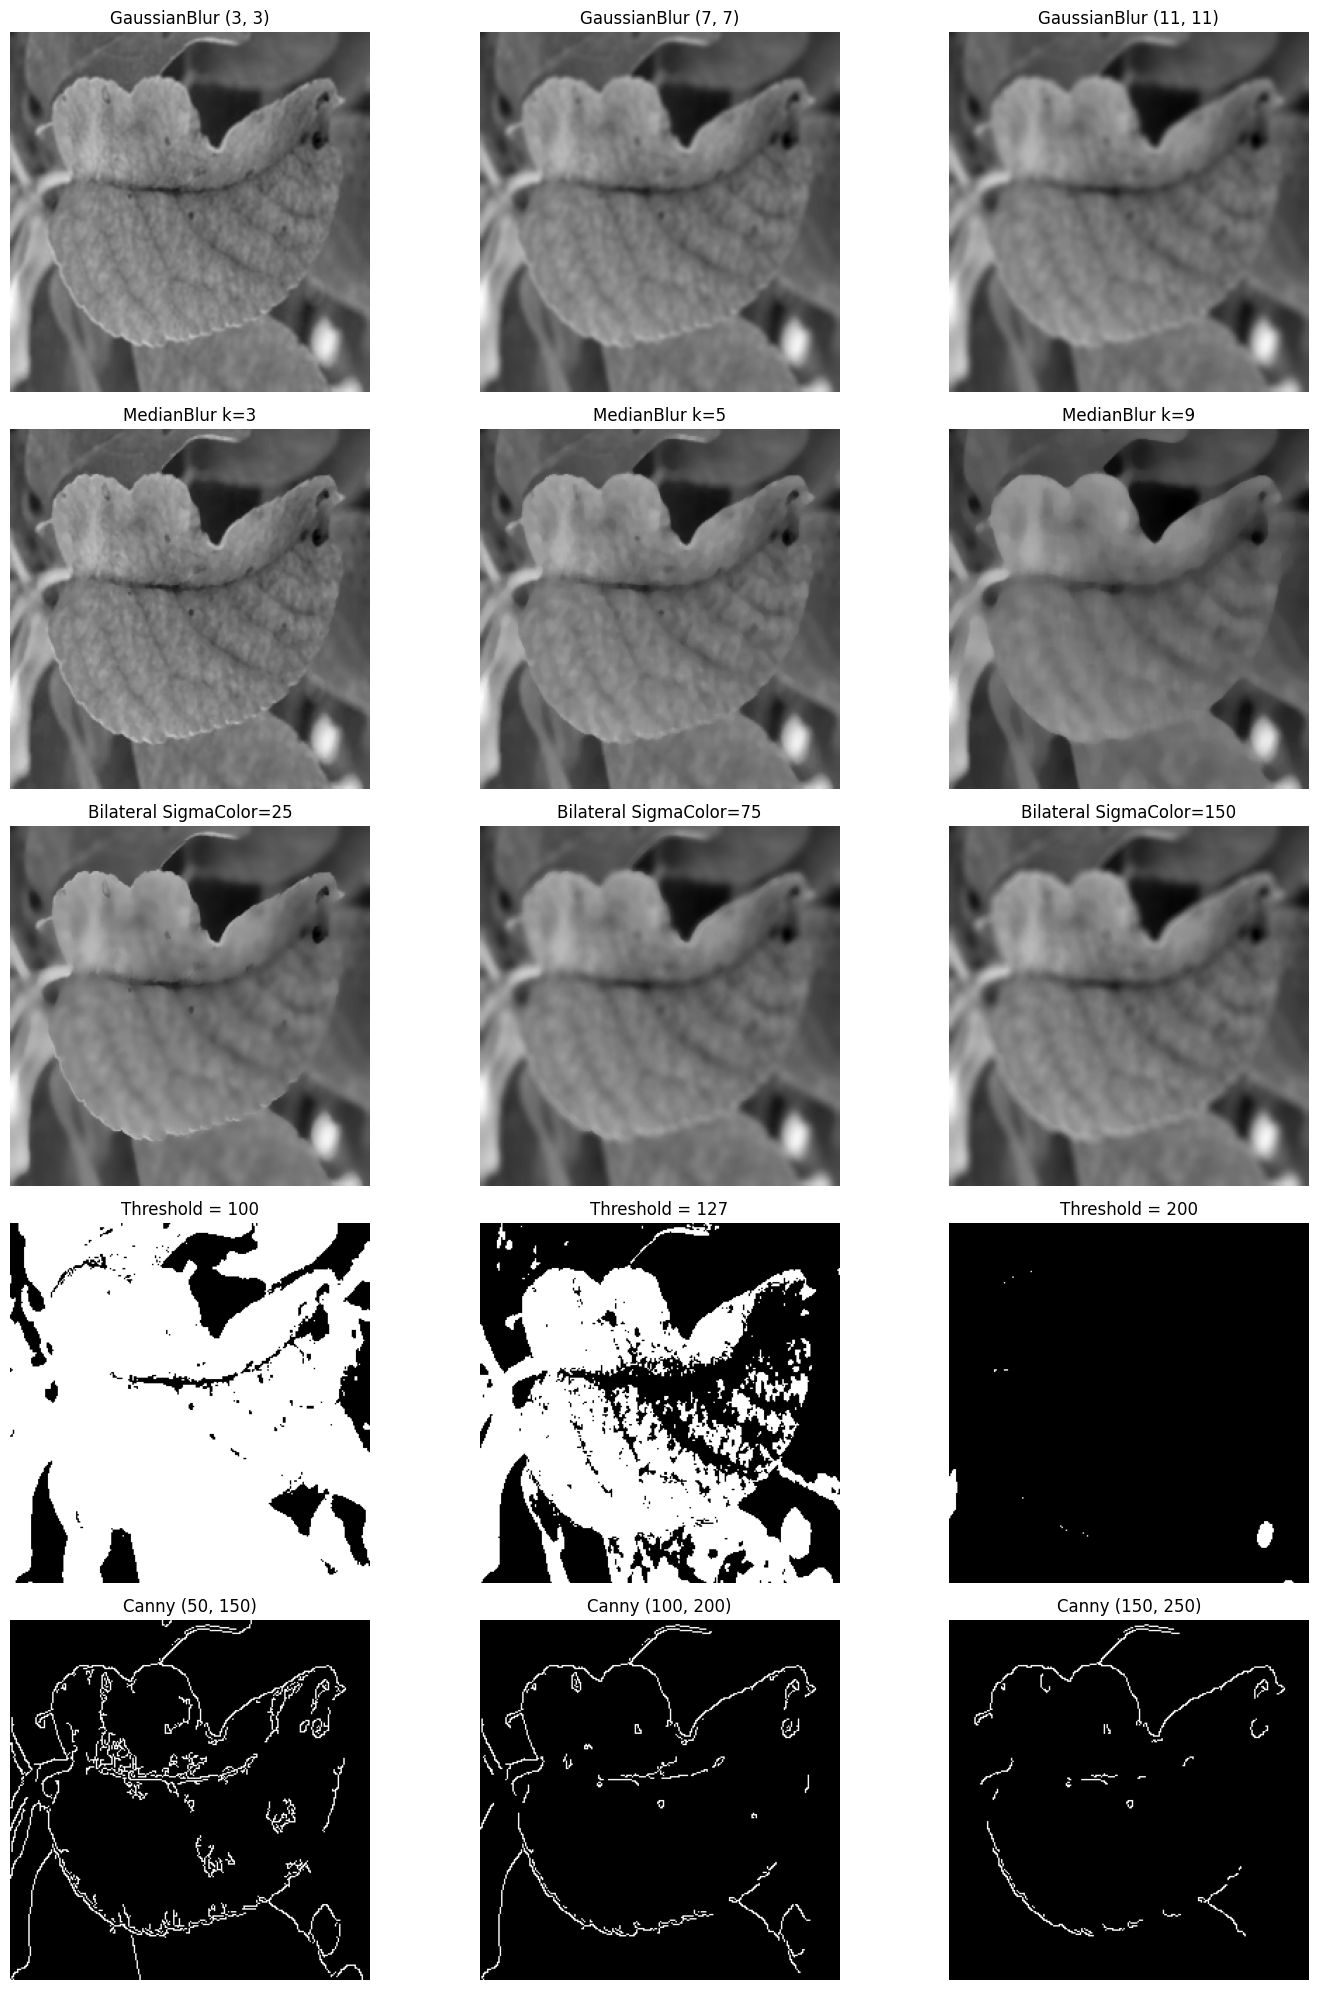

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Pastikan gambar sudah di-load
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(15, 20))

# 1. GaussianBlur - Ukuran Kernel
kernels = [(3,3), (7,7), (11,11)]
for i, k in enumerate(kernels):
    blurred = cv2.GaussianBlur(gray, k, 0)
    plt.subplot(5, 3, i+1)
    plt.imshow(blurred, cmap='gray')
    plt.title(f'GaussianBlur {k}')
    plt.axis('off')

# 2. MedianBlur - Ukuran Kernel
for i, k in enumerate([3,5,9]):
    blurred = cv2.medianBlur(gray, k)
    plt.subplot(5, 3, i+4)
    plt.imshow(blurred, cmap='gray')
    plt.title(f'MedianBlur k={k}')
    plt.axis('off')

# 3. Bilateral Filter - SigmaColor
for i, sigma in enumerate([25, 75, 150]):
    filtered = cv2.bilateralFilter(gray, 9, sigma, sigma)
    plt.subplot(5, 3, i+7)
    plt.imshow(filtered, cmap='gray')
    plt.title(f'Bilateral SigmaColor={sigma}')
    plt.axis('off')

# 4. Threshold
for i, thresh in enumerate([100, 127, 200]):
    _, th = cv2.threshold(gray, thresh, 255, cv2.THRESH_BINARY)
    plt.subplot(5, 3, i+10)
    plt.imshow(th, cmap='gray')
    plt.title(f'Threshold = {thresh}')
    plt.axis('off')

# 5. Canny Edge
canny_params = [(50,150), (100,200), (150,250)]
for i, (t1,t2) in enumerate(canny_params):
    edges = cv2.Canny(gray, t1, t2)
    plt.subplot(5, 3, i+13)
    plt.imshow(edges, cmap='gray')
    plt.title(f'Canny ({t1}, {t2})')
    plt.axis('off')

plt.tight_layout()
plt.show()